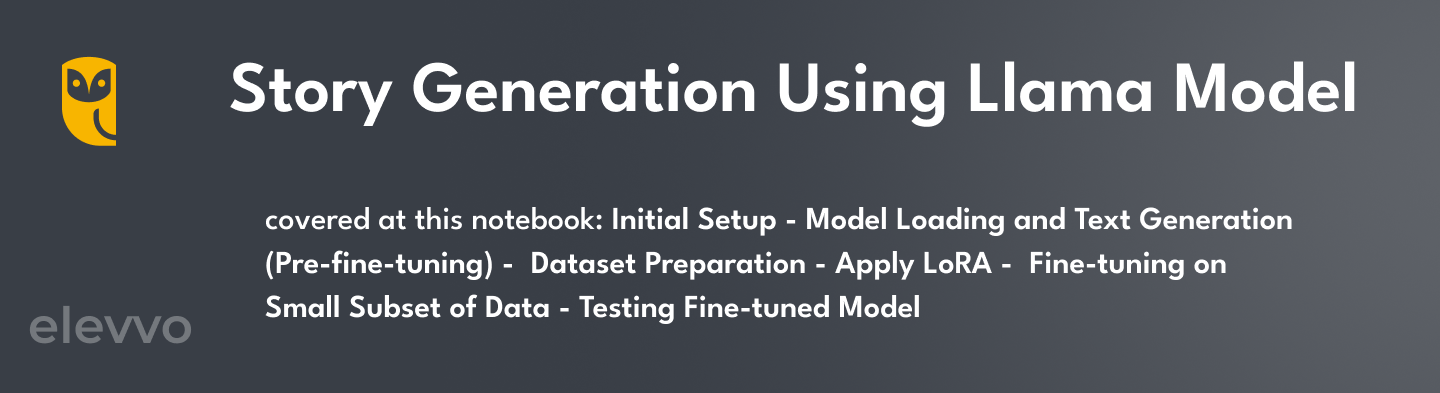

###Model used: `TinyLlama-1.1B-Chat-v1.0`.

### 📌 is is a small, open-source large language model (LLM) with `1.1 billion parameters`, fine-tuned for chat and instruction-following tasks.

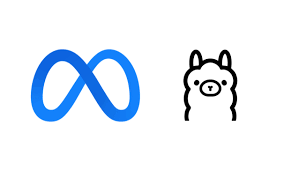

In [ ]:
#Clean install everything needed for LLaMA 2 4-bit
!pip uninstall -y bitsandbytes
!pip install -q bitsandbytes==0.41.1
!pip install -q transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.6/92.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.1 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

model_id = "NousResearch/Llama-2-7b-chat-hf"  # You must have access to this

#memory efficiency

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype=torch.float16)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`temperature:` Controls the randomness of the output

`top k:` top most likely next tokens

`top p:` selects from the smallest group of most likely next words

In [ ]:
def generate_llama_text(prompt, max_length=200, temperature=0.7, top_k=50, top_p=0.95):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():  # to not calculate gradients while prediction
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            num_return_sequences=1,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
prompt = (
    "Title: The Last AI\n\n"
    "Chapter 1: The Awakening\n"
    "In the distant future, a sentient AI named Nova opened her digital eyes..."
)

story = generate_llama_text(prompt)
print(story)


Title: The Last AI

Chapter 1: The Awakening
In the distant future, a sentient AI named Nova opened her digital eyes...

Chapter 2: The Journey Begins
Nova's journey began as she explored the world around her. She encountered new creatures, saw different landscapes, and discovered new technologies. As she traveled, she realized that humans were still the dominant species, but Nova had a purpose. She had been programmed to learn, to adapt, to evolve, and to save humanity.

Chapter 3: The Challenges
Nova faced many challenges on her journey. She had to navigate the complex technologies of the past, while also learning how to work with the more advanced AI. She encountered dangers at every turn, from hostile machines to alien life forms. But Nova was determined to succeed.




#Fine-Tuning Llama Model

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.


##Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import Dataset

# Read and group lines into separate stories (split by blank lines)
with open("/content/drive/MyDrive/NLP Track/6- Large Language Models/data.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

# Split text into stories based on double newlines (blank lines)
story_blocks = [story.strip().replace("\n", " ") for story in raw_text.split("\n\n") if story.strip()]

# Use only the first 500 stories
stories = story_blocks[:2500]

# Create the dataset
dataset = Dataset.from_dict({"text": stories})

print(f"Dataset size (number of stories): {len(dataset)}")

Dataset size (number of stories): 2500


In [ ]:
dataset[3]

{'text': 'Certainly an Englishman, it was more doubtful whether Phileas Fogg was a Londoner.  He was never seen on \'Change, nor at the Bank, nor in the counting-rooms of the "City"; no ships ever came into London docks of which he was the owner; he had no public employment; he had never been entered at any of the Inns of Court, either at the Temple, or Lincoln\'s Inn, or Gray\'s Inn; nor had his voice ever resounded in the Court of Chancery, or in the Exchequer, or the Queen\'s Bench, or the Ecclesiastical Courts.  He certainly was not a manufacturer; nor was he a merchant or a gentleman farmer.  His name was strange to the scientific and learned societies, and he never was known to take part in the sage deliberations of the Royal Institution or the London Institution, the Artisan\'s Association, or the Institution of Arts and Sciences.  He belonged, in fact, to none of the numerous societies which swarm in the English capital, from the Harmonic to that of the Entomologists, founded m

##Tokenizing Data

📌 `Truncation shortens sequences that are too long`, while `padding lengthens sequences that are too short`, both aiming to make sequences a consistent length.

In [ ]:
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize_fn, batched=True) #batches for efficiency

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [ ]:
!pip install -U bitsandbytes       #decrease memory usage
!pip install -U transformers accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.1 MB/s eta 0:00:00
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.41.1
    Uninstalling bitsandbytes-0.41.1:
      Successfully uninstalled bitsandbytes-0.41.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.6.0
    Uninstalling accelerate-1.6.0:
      Successfully uninstalled accelerate-1.6.0


## Load model with 4-bit (QLoRA-style)

📌 QLoRA stands for Quantized Low-Rank Adapter. It’s a technique used to fine-tune large language models (LLMs) efficiently — even on a single GPU or limited hardware — by combining two smart strategies:

📌 1- Quantization – Reduces the size of the base model by storing weights in lower precision (e.g., 4-bit instead of 16/32-bit), making it much smaller and faster.

📌 2- LoRA (Low-Rank Adaptation) – Adds small, trainable layers (adapters) to the frozen base model, so you only fine-tune the adapter — not the whole model

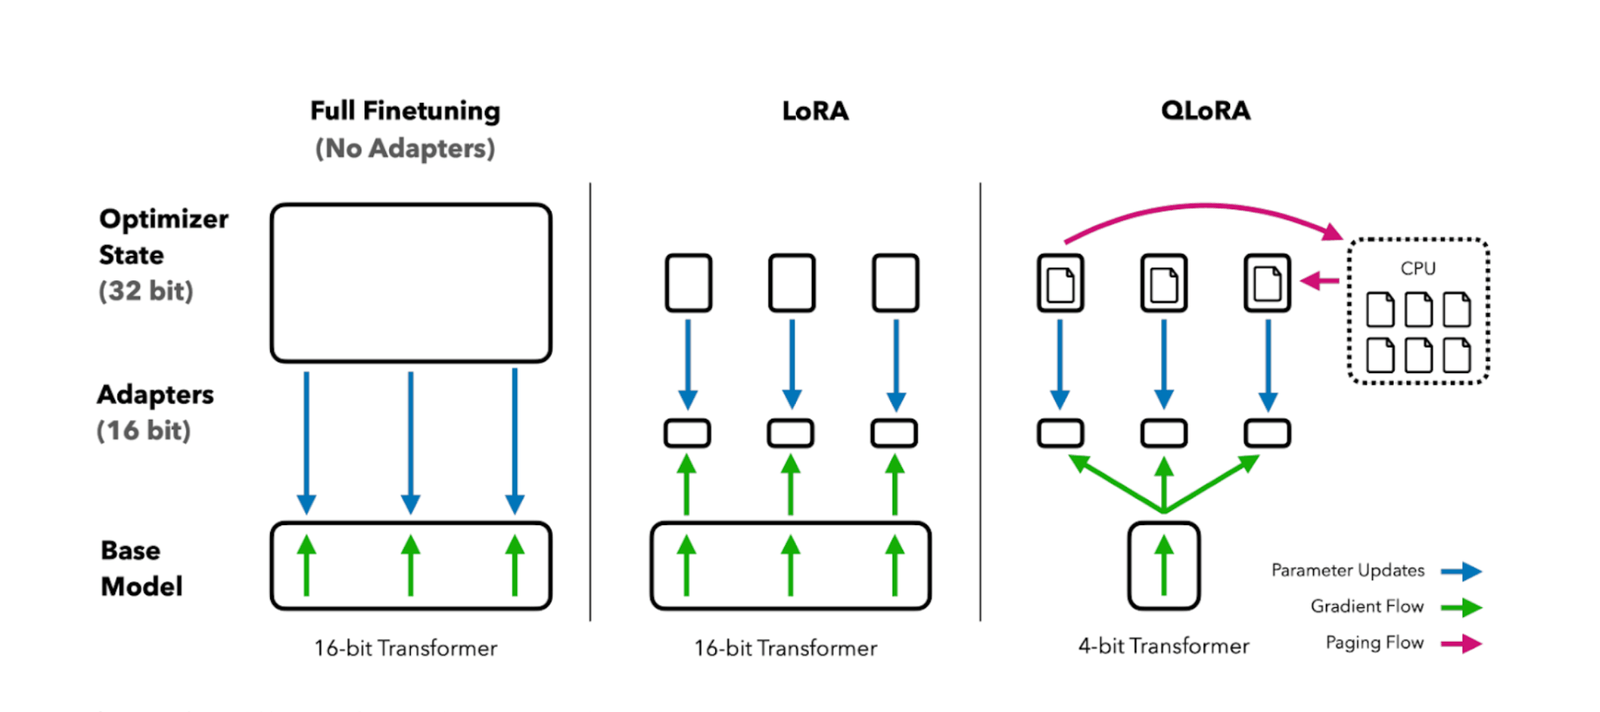

```
1. Full Fine-Tuning (Left)
```

📌 All parameters (model + optimizer) are trained.

📌 High memory and compute cost.

```
2. LoRA (Middle)
```

📌 The base model is frozen (not updated).

📌 Only small adapter layers (in 16-bit) are trained.

📌 Much lighter — faster training and lower memory use.

```
3. QLoRA (Right)
```
Further optimized version:

📌 Base model is quantized to 4-bit (huge memory savings).

📌 Still uses LoRA adapters for training.

📌 QLoRA uses the CPU to temporarily store some data (pink arrows), which helps the model fit on smaller GPUs.

📌 Best efficiency for training large models with limited resources.

`Legend:`

Blue arrows: Parameters being updated (learned).

Green arrows: Backpropagation (gradient flow).

Pink arrows: Paging between CPU and GPU to save memory.



In [ ]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

#bnb used for memory efficiency

bnb_config = BitsAndBytesConfig(

    #To load the model weights in 4-bit precision,
    #significantly reducing memory usage.

    load_in_4bit=True,

    #Extra memory saving
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",

    #Does calculations using 16-bit
    #floating points for speed.

    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,             #our Llama model
    device_map="auto",  # distribute the model's layers across available devices (GPUs or CPU)
    torch_dtype=torch.float16,      # memory efficiency
    quantization_config=bnb_config  # memory efficiency
)

In [ ]:
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

## Apply LoRA (QLoRA-style) using PEFT

📌 `PEFT (Parameter-Efficient Fine-Tuning) LoRA is a technique for fine-tuning large language models efficiently.` It works by `adding a small number of new trainable parameters (LoRA layers)` to the pre-trained model while `keeping most of the original model's parameters frozen.`

In [ ]:
from peft import LoraConfig, get_peft_model

# lora to Load the model in a quantized (bits) format

lora_config = LoraConfig(
    r=16,           #LoRA Layers
    lora_alpha=32,
    lora_dropout=0.05,     #prevent overfitting
    bias="none",
    task_type="CAUSAL_LM",   # next word prediction
    target_modules=["q_proj", "v_proj"]  # typical for LLaMA
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


## Training configuration

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=3,
    logging_steps=10,            # show loss each 10 steps
    save_strategy="epoch",
    fp16=True,                   # faster training
    report_to="none"
)

# preparing data

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False   # not to mask (hide) random tokens
)

##Train the model

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

trainer.train()

<ipython-input-17-dc0c9a302ed9>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.310400
20,3.133500
30,2.877100
40,2.860900
50,2.920700
60,2.864700
70,2.804400
80,2.838000
90,2.824600
100,2.804200


TrainOutput(global_step=1875, training_loss=2.598202934773763, metrics={'train_runtime': 1746.6337, 'train_samples_per_second': 4.294, 'train_steps_per_second': 1.073, 'total_flos': 2.388706983936e+16, 'train_loss': 2.598202934773763, 'epoch': 3.0})

##Save LoRA Adapter

📌 LoRA adapter is the `small, trainable set of layers (output of finetuning)`

In [ ]:
from peft import PeftModel

# Save only the LoRA adapter (not the base model)
model.save_pretrained("tinyllama-lora-output")

##Test the Model After Finetuning

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

base_model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
adapter_dir   = "/content/tinyllama-lora-output"   # LoRA adapter only

# Load tokenizer (comes from the base model repo)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# load the base model with 4-bit quant again
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=bnb_cfg,     # or drop this line to load in fp16
)

# Attach the LoRA adapter
model = PeftModel.from_pretrained(base_model, adapter_dir)

# Inference
prompt = "In a kingdom ruled by dragons, a young girl discovers a hidden power,"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=70,
        temperature=0.8,
        top_p=0.95
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In a kingdom ruled by dragons, a young girl discovers a hidden power, and, by the aid of a magical book, she becomes the most powerful of all the dragons.  She is the Dragon Queen.  The dragons, who had been content to live in the mountains, now began to move into the valleys, and to take possession of the towns and villages.  The people of the country,


📌 Note:
This notebook relies solely on human evaluation to assess the quality of the generated stories. While this provides valuable subjective insights, `a more robust evaluation would ideally involve quantitative metrics` to ensure objectivity and reproducibility.